# Assignment 2: Industry Competition in Seattle

**Author:** Shanmukh Upadhyayula

**Date:** 21 March 2026

**Overview:** In this assignment, I analyze spatial point patterns of industries across Seattle in 1998 and 2001 from the GeoDa "Industry Competition in Seattle (2000)" dataset. I wrangle the data by converting the ZIP code attribute to centroids and visualizing the industry distribution and visualizing various statistical measures such as the mean center, standard deviational ellipse, or convex hull.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from pointpats import centrography
import seaborn as sns

## Data Description, Loading, & Inspection

**Source:** GeoDa- https://geodacenter.github.io/data-and-lab/seattle2/

**Why Chosen:** I have selected this dataset because it is interesting to see how economic activity clusters together in a city. Additionally, in GGIS 379, everyone is assigned a state to analyze throughout the course, and I chose Washington so it is nice to continue that analysis here in GGIS 371.

**Dataset file type:** I have selected to use GeoJSON as it is easier to work with than shapefiles and it is spatial data unlike a csv file.

**CRS:** The default CRS is EPSG: 4326 but I have changed it to EPSG: 6596 since it is projected to Seattle instead of remaining unprojected.


In [2]:
seattle_industries = gpd.read_file("..\Data\Assignment2Data\SeattleMSA2\SeattleMSA2.geojson")

<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\shanm\AppData\Local\Temp\ipykernel_17132\3487072090.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  seattle_industries = gpd.read_file("..\Data\Assignment2Data\SeattleMSA2\SeattleMSA2.geojson")


In [3]:
seattle_industries.shape

(145, 56)

In [4]:
seattle_industries.head()

,ZIP,PO_NAME,STATE,POP2001,MSA,EST98,EMP98,PAY98,EST01,EMP01,...,INFOUS01_1,INFOUS01_3,INDEX,NUMSEC,PCTNGE,PCTIME,PCTCSE,PCTGRO,ID,geometry
0,98241,DARRINGTON,WA,1940,Seattle,40,468,13299,41,455,...,89935,47358,659,13,2.21,-1.25,-7.78,-6.82,0,"MULTIPOLYGON (((-120.90621 48.16385, -120.9615..."
1,98223,ARLINGTON,WA,36244,Seattle,810,9353,259006,837,8722,...,89935,47358,657,21,2.21,-0.37,0.35,2.20,1,"MULTIPOLYGON (((-122.11132 48.07199, -122.1118..."
2,98292,STANWOOD,WA,17897,Seattle,621,3871,84210,483,3473,...,89935,47358,669,19,2.21,-0.06,8.32,10.47,2,"MULTIPOLYGON (((-122.26554 48.13928, -122.2664..."
3,98252,GRANITE FALLS,WA,7023,Seattle,108,533,11931,120,673,...,89935,47358,661,19,2.21,-0.29,3.34,5.26,3,"MULTIPOLYGON (((-121.45158 47.9686, -121.45141..."
4,98271,MARYSVILLE,WA,23362,Seattle,253,3591,106708,311,4431,...,89935,47358,664,19,2.21,-1.10,13.65,14.76,4,"MULTIPOLYGON (((-122.18372 48.03679, -122.1837..."


In [5]:
seattle_industries.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
seattle_industries = seattle_industries.to_crs(epsg=6596)
seattle_industries.crs

<Projected CRS: EPSG:6596>
Name: NAD83(2011) / Washington North
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Washington - counties of Chelan; Clallam; Douglas; Ferry; Grant north of approximately 47°30'N; Island; Jefferson; King; Kitsap; Lincoln; Okanogan; Pend Oreille; San Juan; Skagit; Snohomish; Spokane; Stevens; Whatcom.
- bounds: (-124.79, 47.08, -117.02, 49.05)
Coordinate Operation:
- name: SPCS83 Washington North zone (meter)
- method: Lambert Conic Conformal (2SP)
Datum: NAD83 (National Spatial Reference System 2011)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

## Point Data Visualization


In [7]:
seattle_centroids = seattle_industries.copy()
seattle_centroids["geometry"] = seattle_industries.geometry.centroid
seattle_centroids["x"] = seattle_centroids.geometry.x
seattle_centroids["y"] = seattle_centroids.geometry.y
seattle_centroids[["x", "y"]].describe()

,x,y
count,145.000000,145.000000
mean,395175.042455,56084.276914
std,18561.113588,33691.378255
min,360893.666374,-25823.551023
25%,384616.106069,28878.424149
50%,390377.111581,60972.434598
75%,402213.553430,77258.400181
max,465819.398964,136737.595714


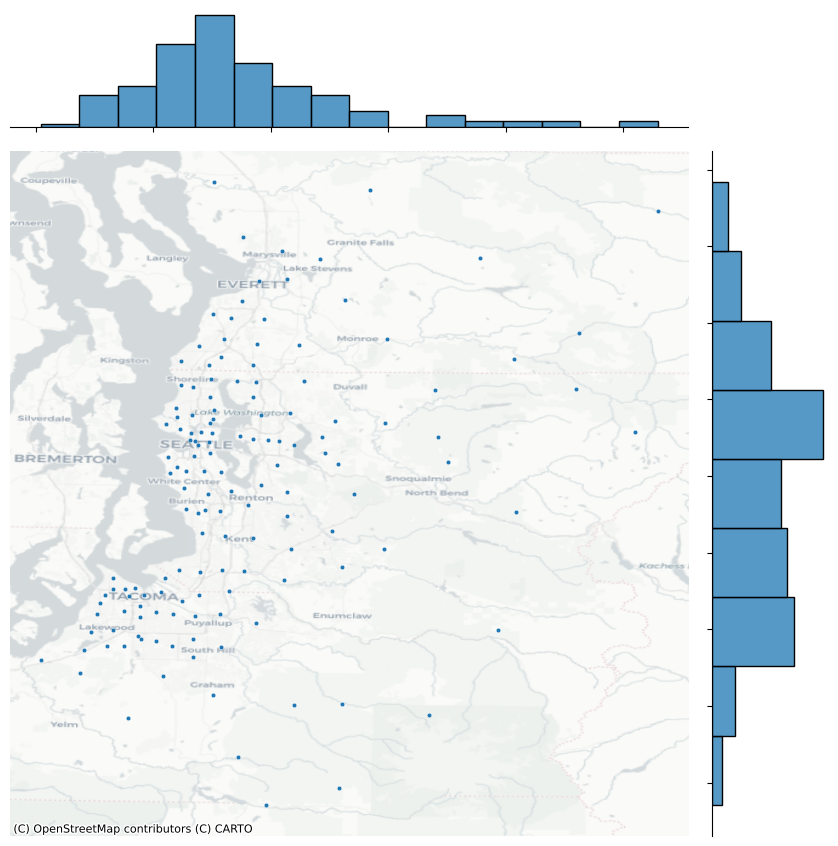

In [8]:
joint_axes = sns.jointplot(
    x="x", y="y", data=seattle_centroids, s=10, height=9
)
ctx.add_basemap(
    joint_axes.ax_joint,
    crs=seattle_centroids.crs.to_string(),
    source=ctx.providers.CartoDB.Positron
)
joint_axes.ax_joint.set_axis_off()
plt.show()